## Instructions

**Due: Thursday, September 17, 2026 11:59 PM EDT — Submit via Gradescope**

### Introduction
In this project, you will design an algorithm for a warehouse intake robot at an aerospace company that sorts incoming items into one of five physical form factors. A similar trash sorting robot is described in the [textbook](http://www.roboticsbook.org/intro.html). Please refer to [Section 2](http://www.roboticsbook.org/S20_sorter_intro.html) of the book to follow along the logic. **This project is similar to Section 2 of the textbook.**

### Project Overview
This assignment is divided into three parts:
1. **Core Algorithm Implementation** (see `CS3630Proj2.ipynb`, `main.py`): In this part, you will model the problem in Python and implement the decision algorithm using NumPy.
2. **GTSAM Practice**: In this part, you will utilize GTSAM (its Python bindings) to solve the same problem. This section will be fairly short as you'll realize most of the logic is the same.
3. **Extra Credit (Learning)**: In this optional part, you will practice determining the distribution of a sensor using statistical estimates.
4. **Reflection** (see `project2.tex`): In this part, you will complete some problems related to the material in this unit, and answer questions related to the project.

### Problem Context

#### Package Classes
The intake robot must route each item to one of five classes:
- **P** — 3D printed products
- **S** — Structural bracings
- **B** — PCB boards for the flight computer
- **W** — Wing components (typically made of carbon fiber)
- **M** — Motors for control surfaces

#### Sensors
- **Weight sensor**: returns the package's weight in grams.
- **Thickness sensor**: returns the package's thickness. Three possible values: Thin, Medium, and Thick.
- **Rigidity sensor**: returns how rigid the package is. Two possible values: Rigid and Flexible.
- **Surface material sensor**: returns the surface material. Three possible values: Plastic, Metal, and Ceramic.

We assume conditional independence in the sensor readings when given the package's class.

### Provided Models

#### Priors

| Class | P | S | B | W | M |
|---|---|---|---|---|---|
| Probability | 0.3 | 0.2 | 0.35 | 0.1 | 0.05 |

#### Weight Model

| Class | P | S | B | W | M |
|---|---|---|---|---|---|
| Mean | 150 | 800 | 50 | 250 | 600 |
| Std. dev. | 75 | 400 | 25 | 125 | 300 |

#### Thickness Category — P(Thickness | Class)

| Class | Thin | Medium | Thick |
|---|---|---|---|
| P | 0.9 | 0.1 | 0.0 |
| S | 0.0 | 0.2 | 0.8 |
| B | 0.3 | 0.55 | 0.15 |
| W | 0.0 | 0.8 | 0.2 |
| M | 0.4 | 0.50 | 0.1 |

#### Rigidity — P(Rigidity | Class)

| Class | Rigid | Flexible |
|---|---|---|
| P | 0.2 | 0.8 |
| S | 0.9 | 0.1 |
| B | 0.8 | 0.2 |
| W | 0.4 | 0.6 |
| M | 0.3 | 0.7 |

#### Surface Material — P(Material | Class)

| Class | Plastic | Metal | Ceramic |
|---|---|---|---|
| P | 0.95 | 0.02 | 0.03 |
| S | 0.05 | 0.85 | 0.1 |
| B | 0.05 | 0.35 | 0.6 |
| W | 0.80 | 0.15 | 0.05 |
| M | 0.10 | 0.85 | 0.05 |

#### Cost Table

| Action \ Class | P | S | B | W | M |
|---|---|---|---|---|---|
| Printed Bin | 0 | 8 | 10 | 20 | 18 |
| Structural Bin | 2 | 0 | 4 | 14 | 12 |
| Board Bin | 3 | 3 | 0 | 6 | 6 |
| Wing Bin | 14 | 12 | 6 | 0 | 5 |
| Motor Bin | 16 | 14 | 6 | 5 | 0 |

### Deliverables & Grading

#### Deliverables
- Submit `main.py` to the **code assignment** on Gradescope.
- Submit your compiled `project2.tex` as a PDF to the **reflection assignment** on Gradescope. Assign every question to the correct page — a penalty of 1 point is applied for each incorrectly assigned or unassigned question.

#### Grading
- **60 Pts** for coding, **40 Pts** for reflection questions.
- No score/partial score will be given if your implementation crashes on the autograder. It is your responsibility to ensure your code runs correctly.
- Submissions open on September 8, 2026 11:59 PM.
- For late submission policy, see the syllabus.

### Honor Code and Use of AI
See the syllabus for expectations related to academic integrity and use of AI.

### Tips
- We do not support using Colab for this (or future) assignments. We recommend you solve the questions in an IDE such as VS Code or PyCharm.
- For NumPy reference, use: https://numpy.org/doc/2.3/
- For GTSAM reference, use: https://borglab.github.io/gtsam/ — additionally, the online textbook has useful code snippets on how to use GTSAM.

## How to work on this project

All of the code you write lives in **`main.py`**. Every `TODO` is a function
there, to be filled in between its `START OF YOUR CODE` and `END OF YOUR CODE`
markers. Do not change any function's signature.

This notebook defines none of that code. It imports `main.py` and runs the
sanity checks against it. The reflection questions are listed at the bottom
of this notebook — put your answers in `project_reflections.pptx`. After
completing your code, follow `webots/STUDENT_SETUP_AND_NAVIGATION.md` to run
the Webots visualization. `%autoreload 2` is turned on below, so after you
edit and save `main.py` you can simply re-run a test cell -- no kernel restart
needed.

**Submit `main.py` to the code assignment on Gradescope, and
`project_reflections.pptx` to the reflection assignment.**

In [1]:
# To use on colab, uncomment the following lines
# %pip install -U -q gtbook
# %pip install gtsam

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
from main import (
    CLASSES,
    Gaussian,
    Material,
    Rigidity,
    Thickness,
    bayes_given_all_sensors,
    bayes_given_all_sensors_gtsam,
    bayes_given_weight,
    fit_log_normal,
    get_item_prior_pmf,
    get_item_prior_pmf_gtsam,
    get_pMT,
    get_pRT,
    get_pTT,
    get_pWT,
    make_decision,
    posterior_no_sensors,
    sample_item,
    sample_item_gtsam,
    sample_material,
    sample_material_gtsam,
    sample_rigidity,
    sample_rigidity_gtsam,
    sample_thickness,
    sample_thickness_gtsam,
    sample_weight,
)

Import the unit test file we just uploaded.

In [3]:
from project2_test import TestProject2, verify

np.random.seed(3630)
unit_test = TestProject2()

## Part I: Decision Algorithm in NumPy [70 Pts]

### I.1 Modeling the World State
- Functions to complete: **TODO 1** and **TODO 2**
- Objective: Representing the prior probabilities of the package categories and simulate it by sampling.

#### **TODO 1: Priors PMF** [5 Pts]


In [4]:
print("Testing item prior PMF: ", verify(unit_test.test_get_item_prior_pmf, get_item_prior_pmf))

Testing item prior PMF:  "Correct"


#### **TODO 2: Sampling from Prior** [5 Pts]

In [5]:
print("Testing item sampling: ", verify(unit_test.test_sample_item, sample_item))

Testing item sampling:  "Correct"


### I.2 Actions for Sorting Items
- Functions to complete: TODO 3.
- Objective: Representing actions and their corresponding costs.

    Generate the cost table, where the rows correspond
    to ACTIONS and the columns correspond to CATEGORIES.

#### **TODO 3: Defining the cost table** [5 Pts]

### I.3 Sensors for Sorting Items
- Functions to complete: TODO 4-7
- Objective: Representing conditional probabilities of new sensors.

#### **TODO 4: Sample Weight** [5 Pts]
Sample the weight of the package given the item category. If the class is not given, sample a category first.

In [6]:
print("Testing weight sampling: ", verify(unit_test.test_sample_weight, sample_weight))

Testing weight sampling:  "Correct"


#### **TODO 5: Sample Thickness** [5 Pts]
Sample the thickness of the package given the item category. If the class is not given, sample a category first.

In [7]:
print("Testing thickness sampling: ", verify(unit_test.test_sample_thickness, sample_thickness))

Testing thickness sampling:  "Correct"


#### **TODO 6: Sample Rigidity** [5 Pts]
Sample the rigidity of the package given the item category. If the class is not given, sample a category first.

In [8]:
print("Testing rigidity sampling: ", verify(unit_test.test_sample_rigidity, sample_rigidity))

Testing rigidity sampling:  "Correct"


#### **TODO 7: Sample Material** [5 Pts]
Sample the material of the package given the item category. If the class is not given, sample a category first.

In [9]:
print("Testing material sampling: ", verify(unit_test.test_sample_material, sample_material))

Testing material sampling:  "Correct"



### I.4 Perception
- Function to complete: TODO 8.
- Objective: Calculating posterior probabilities using sensor observations.

#### **TODO 8: Bayes Given All Sensors** [5 Pts]

In [10]:
print(
    "Testing Bayesian inference: ",
    verify(unit_test.test_bayes_given_all_sensors, bayes_given_all_sensors),
)

Testing Bayesian inference:  "Correct"


### I.5. Decision Theory
- Function to complete: TODO 9.
- Objective: Incorporating the cost table with perception to make a final decision.

#### **TODO 9: Making The Sorting Decision** [5 Pts]

In [11]:
print("Testing decision making: ", verify(unit_test.test_make_decision, make_decision))

Testing decision making:  "Correct"


### I.6 Running Our Algorithm
In this subsection, we'll test our algorithm on a typical structural bracing, and test if the decision it makes is correct.

In [12]:
### EXAMPLE RUN ###
# Let's simulate a Structural Bracing and see what the robot does.
# A structural bracing is typically: heavy, thick, rigid, and made of metal.
print("\n--- SIMULATION: Testing with a typical Structural Bracing ---")
simulated_weight = 820.0  # grams
simulated_thickness = Thickness.THICK.value  # 2
simulated_rigidity = Rigidity.RIGID.value  # 0
simulated_material = Material.METAL.value  # 1

# print(
#     f"Sensor readings: Weight={simulated_weight}g, "
#     f"Thickness={Thickness(simulated_thickness).name}, "
#     f"Rigidity={Rigidity(simulated_rigidity).name}, "
#     f"Material={Material(simulated_material).name}"
# )

# Calculate posterior probabilities based on these readings
posteriors = bayes_given_all_sensors(
    simulated_weight, simulated_thickness, simulated_rigidity, simulated_material
)

print("\nPosterior Probabilities:")
for i, p in enumerate(posteriors):
    print(f"  P({CLASSES[i]} | sensors) = {p:.4f}")

# Make a decision
decision_index = make_decision(posteriors)
decision_class = CLASSES[decision_index]

print(f"\nRobot's Decision: Sort as a '{decision_class}'")
if decision_class == "Structural_Bracing":
    print("Correct decision! (CORRECT)")
else:
    print("Incorrect decision. (INCORRECT)")


--- SIMULATION: Testing with a typical Structural Bracing ---

Posterior Probabilities:
  P(3D_Printed_Product | sensors) = 0.0000
  P(Structural_Bracing | sensors) = 0.9895
  P(PCB_Board | sensors) = 0.0000
  P(Wing_Component | sensors) = 0.0000
  P(Motor | sensors) = 0.0105

Robot's Decision: Sort as a 'Structural_Bracing'
Correct decision! (CORRECT)


In [13]:
# Placeholder code block for plot for Q2

In [14]:
# Placeholder code block for Q3

## Part II: Decision Algorithm in GTSAM [30 Pts]

Now we would use `gtsam` to solve the above.

### II.1 Modeling with GTSAM
- Functions to complete: TODO 10-11.
- Objective: Model the same problem with GTSAM.



#### **TODO 10 & TODO 11: Get Prior using GTSAM** [2 Pts]

In [15]:
print("Testing your prior probabilities of the item classes: ")
print(verify(unit_test.test_get_item_prior_pmf, get_item_prior_pmf_gtsam))

Testing your prior probabilities of the item classes: 
"Correct"


#### **TODO 12: Sampling with GTSAM** [1 Pt]

In [16]:
print("Testing item sampling: ", verify(unit_test.test_sample_item, sample_item_gtsam))

Testing item sampling:  "Correct"


### II.2 Sensors in GTSAM
- Functions to complete: TODO 13-18
- Objective: Model the sensors using GTSAM.

#### **TODO 13-18: Update Sensor Models** [1 Pt each, 6 Pts Total]

In [17]:
print(
    "Testing thickness sampling: ", verify(unit_test.test_sample_thickness, sample_thickness_gtsam)
)

Testing thickness sampling:  "Correct"


In [18]:
print(
    "Testing your sample rigidity: ", verify(unit_test.test_sample_rigidity, sample_rigidity_gtsam)
)

Testing your sample rigidity:  "Correct"


In [19]:
print("Testing material sampling: ", verify(unit_test.test_sample_material, sample_material_gtsam))

Testing material sampling:  "Correct"


### II.3 Perception with GTSAM
- Functions to complete: TODO 19-21
- Objective: Perform perception using GTSAM.

#### **TODO 19: Posterior with No Sensors** [1 Pt]

In [20]:
print("Testing your posterior with no sensors: ")
print(verify(unit_test.test_posterior_no_sensor, posterior_no_sensors))

Testing your posterior with no sensors: 
"Correct"


#### **TODO 20-21: Weight Likelihood and Weight Bayes** [TODO 20: 1 Pt, TODO 21: 2 Pts]

In [21]:
print("Testing your posteriors with the weight sensor and priors: ")
print(verify(unit_test.test_bayes_given_weight, bayes_given_weight))

Testing your posteriors with the weight sensor and priors: 
"Correct"


#### **TODO 22: Bayes with All Sensors** [2 Pts]

In [22]:
print(
    "Testing Bayesian inference: ",
    verify(unit_test.test_bayes_given_all_sensors, bayes_given_all_sensors_gtsam),
)

Testing Bayesian inference:  "Correct"


We have now completed the perception using GTSAM! You can reuse the decision logic from part I to make the min expected cost decision. Now you know how to implement this project using GTSAM!

## Part IV: Learning--Extra Credit ([Book Section 2.6](http://www.roboticsbook.org/S26_sorter_learning.html)) [5 Pts]





A Gaussian distribution, also known as a normal distribution, is an inappropriate distribution to represent
the weight of an item. This is because it has an infinite range and therefore sampling from it can produce
a negative number, while an item cannot have a negative weight. A more commonly used distribution
used to represent weight is the [log-normal distribution](https://en.wikipedia.org/wiki/Log-normal_distribution) which can only contain positive real values. The book explains how to fit a gaussian distribution to a set of data. For extra credit, we would like you to implement a function.
- Functions to complete: **TODO 23** in the cell below.
- Objective: Fit a Log-Normal Distribution to a set of data.
- Hint: There is an estimation of parameters section on the wikipedia article.

#### **TODO 23: Fitting The Log Normal Distribution** [5pts]

In [23]:
print(
    "Testing your log-normal distribution: ", verify(unit_test.test_fit_log_normal, fit_log_normal)
)

1.0335147131414777 0.5111549289460514
Testing your log-normal distribution:  "Correct"


## Reflection Questions [40 Pts]

**Put your answers in `project_reflections.pptx` and submit to the Reflection assignment on Gradescope.**

### Part I: Math Review from the Unit [10 Pts]

**Q1** [4 Pts] The probability of it being rainy in Atlanta is 60%. The probability of having an exam at Georgia Tech on a given weekday is 10%. If the probability of it being rainy on an exam day is 30%, what's the probability of an exam day not being on a rainy day?

**Q2** [3 Pts] If we roll two fair dice: one with values 1,3,5,7 and the other with values 2,4,6,8,10,12, what is the expected value of their sum?

**Q3** [3 Pts] In a standard deck of 52 cards, what is the probability that a card is in the Clubs suite and is greater than 3 (count Ace as 1)?

### Part II: Decision Algorithm in NumPy [20 Pts]

**Q4** [5 Pts] If a sensor goes faulty and gives random measurements, explain how the current implementation helps the robot arrive at a decision.

**Q5** [10 Pts] In your own words, explain what happens inside the `bayes_given_all_sensors` function. How does the robot arrive at a more confident belief? Explain by **plotting** the distribution after combining each sensor how the robot becomes more confident in a decision. You may import matplotlib or plotly for this question. Make sure to also include the plots in your final submission.

**Q6** [5 Pts] Update the cost table in a way such that the robot always sorts the items in the wrong box. Give a short **proof** for your cost table selection. You are welcome to provide the proof in text or in code.

### Part III: Decision Algorithm in GTSAM [10 Pts]

**Q7** [2 Pts] What is the purpose of `gtsam.DiscreteDistribution()` in your implementation?

**Q8** [2 Pts] When sampling sensor values (e.g., thickness, rigidity, material) using GTSAM, which function did you use and why?

**Q9** [2 Pts] What are the main differences between implementing Bayesian inference manually (with NumPy) and using GTSAM? What benefits or challenges did you encounter when using GTSAM?

**Q10** [2 Pts] Complete one automatic five-item run using your own `main.py`. Choose one item and include a readable screenshot of the ABB arm holding or releasing it. From the Webots console, report its four sensor values, the five posterior values returned by `bayes_given_all_sensors(...)`, the action returned by `make_decision(...)`, and the matching destination bin. Explain how the one-to-one action-to-bin mapping turns your probabilistic decision into the visible warehouse route.

**Q11** [2 Pts] Choose a second item that your code sends to a different bin and include a readable screenshot of that route. Report the action and destination bin for both items. Briefly explain how changing the action changed where the robot moved, and identify one visible motion the arm or claw used to complete the second route.

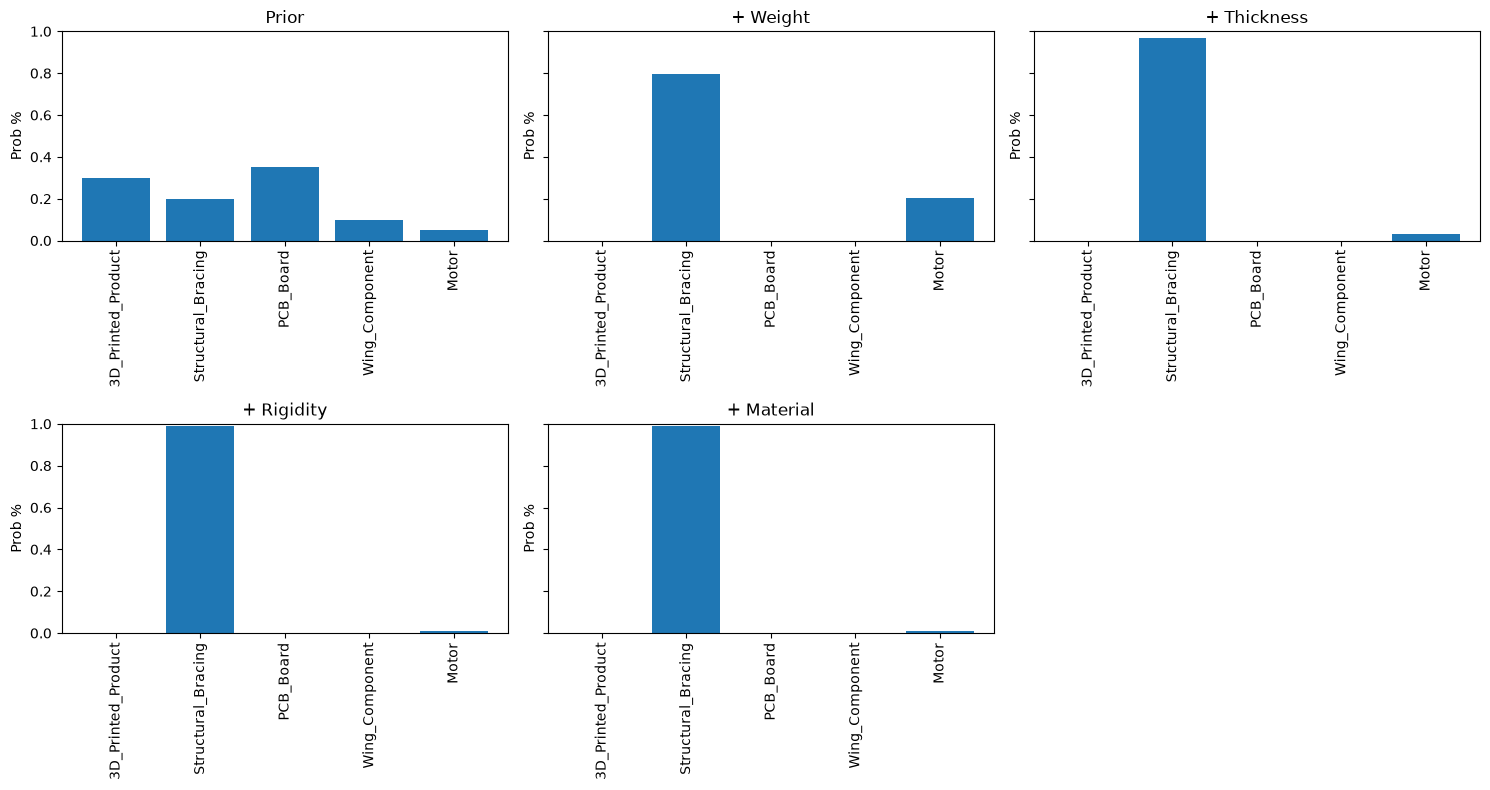

In [26]:
import matplotlib.pyplot as plt
import numpy as np

weight = 820.0
thickness = Thickness.THICK.value
rigidity = Rigidity.RIGID.value
material = Material.METAL.value

belief = np.array(get_item_prior_pmf(), dtype=float)

weight_likelihood = np.array([Gaussian(weight, mean, std_dev) for mean, std_dev in get_pWT()])

sensor_likelihoods = [
    weight_likelihood,
    get_pTT()[:, thickness],
    get_pRT()[:, rigidity],
    get_pMT()[:, material],
]

stage_names = [
    "Prior",
    "+ Weight",
    "+ Thickness",
    "+ Rigidity",
    "+ Material",
]

beliefs = [belief.copy()]

for likelihood in sensor_likelihoods:
    belief = belief * likelihood
    belief = belief / belief.sum()
    beliefs.append(belief.copy())

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
axes = axes.flatten()

for ax, name, distribution in zip(axes, stage_names, beliefs, strict=False):
    ax.bar(CLASSES, distribution)
    ax.set_title(name)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=90)
    ax.set_ylabel("Prob %")

axes[-1].axis("off")
plt.tight_layout()
plt.show()